In [87]:
# uncomment if needed
# !pip install scikit-learn
# !pip install transformers
# !pip install matplotlib
# !pip install seaborn
# !pip install PySastrawi
# !pip install keras
# !pip install imblearn
# !pip install fasttext
# !pip install wordcloud

In [88]:
import pandas as pd
import re

In [89]:
# --- Settings -------------------------------------------------------------
RAW_URL = "https://raw.githubusercontent.com/furaihan/proyek-data-mining/refs/heads/main/main.json"
TARGET_NAME = "data.json"        # final filename on disk
SAVE_TO_DRIVE = False            # set True to keep it in your Google Drive
DRIVE_FOLDER = "/content/drive/MyDrive/datasets"  # only used if SAVE_TO_DRIVE=True
# -------------------------------------------------------------------------

# 1️⃣  (Optional) Mount Google Drive
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    !mkdir -p "{DRIVE_FOLDER}"

# 2️⃣  Fetch the file and write it out
import requests, pathlib, time

def download_raw(url, outfile):
    t0 = time.time()
    r = requests.get(url, timeout=60)
    r.raise_for_status()               # 🔴 throws an error if 4xx/5xx
    pathlib.Path(outfile).write_bytes(r.content)
    print(f"✅ Saved {outfile}  ({len(r.content):,} bytes, {(time.time()-t0):.2f}s)")

out_path = f"{DRIVE_FOLDER}/{TARGET_NAME}" if SAVE_TO_DRIVE else TARGET_NAME
download_raw(RAW_URL, out_path)

# 3️⃣  Peek to confirm
!head -n 5 "{out_path}"


✅ Saved data.json  (2,681,346 bytes, 0.56s)


'head' is not recognized as an internal or external command,
operable program or batch file.


In [90]:
df = pd.read_json('data.json')
df.head()

,title,label,label_score
0,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...",non-clickbait,0
1,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,non-clickbait,0
2,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,clickbait,1
3,"Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...",non-clickbait,0
4,"Terkait Mayat Bayi Mengenaskan di Tangerang, S...",non-clickbait,0


<Axes: ylabel='count'>

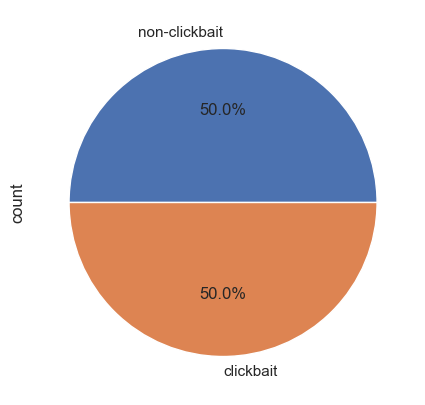

In [91]:
from matplotlib import pyplot as plt
import seaborn as sns

# pie plot with sns
plt.figure(figsize=(5, 5))
sns.set_theme()
df['label'].value_counts().plot.pie(autopct='%1.1f%%')

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        17420 non-null  object
 1   label        17420 non-null  object
 2   label_score  17420 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 408.4+ KB


In [93]:
df.isnull().sum()

title          0
label          0
label_score    0
dtype: int64

# Preprocessing

In [94]:
from nltk.tokenize import word_tokenize
# tf idf
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
factory = StemmerFactory()
stopword_factory = StopWordRemoverFactory()
stopword_indonesia = stopword_factory.get_stop_words()
stemmer = factory.create_stemmer()

In [95]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [96]:
def preprocess_text(text):
    # remove non-alphabet characters
    text = re.sub(r'[^A-Za-z0-9!?]', ' ', text)
    text = re.sub(r'([!?])', r' \1 ', text)
    # remove whitespace
    text = text.strip()
    # remove newline
    text = text.replace('\n', ' ')
    # remove extra space
    text = re.sub(' +', ' ', text)
    # lowercase
    text = text.lower()
    # tokenize
    text = word_tokenize(text)
    # replace punctuation tokens
    text = ['EXCLAMATIONTOKEN' if token == '!' else 'QUESTIONTOKEN' if token == '?' else token for token in text]
    result = text
    return result

In [97]:
df['preprocessed_text'] = df['title'].apply(preprocess_text)
df['stemmed_text'] = df['preprocessed_text'].apply(lambda x: [stemmer.stem(word) for word in x]);

In [98]:
# convert back to exclamation and question tokens
df['stemmed_text'] = df['stemmed_text'].apply(lambda x: ['!' if word == 'exclamationtoken' else '?' if word == 'questiontoken' else word for word in x])

In [99]:
# calculate how many empty word in all stemmed accross all data
empty_word = 0
for i in range(len(df)):
    empty_word += df['stemmed_text'].iloc[i].count('')
print(empty_word)


0


In [100]:
# remove empty word
df['stemmed_text'] = df['stemmed_text'].apply(lambda x: [word for word in x if word != ''])

# Analisis Data

In [101]:
df['stopword_removed'] = df['stemmed_text'].apply(lambda x: [word for word in x if word not in stopword_indonesia])
# remove number in stopword removed
df['stopword_removed'] = df['stopword_removed'].apply(lambda x: [word for word in x if not word.isnumeric()])

In [102]:
df_clickbait = df[df['label'] == 'clickbait']
df_non_clickbait = df[df['label'] == 'non-clickbait']

# Feature Engineering

In [103]:
angka = ['nol', 'satu', 'dua', 'tiga', 'empat', 'lima', 'enam', 'tujuh', 'delapan', 'sembilan']
potential_clickbait_words = ['bikin', 'viral', 'gara', 'fakta', 'kejut', 'kamu', 'wajib', 'pakai', 'ala', 'heboh', 'geger', 'video', 'foto', 'cantik']

def count_full_word_capitals(text):
    return sum(len(word) for word in text.split() if word.isupper() and len(word) > 1)

def count_all_caps_words(text):
    return sum(1 for word in text.split() if word.isupper() and len(word) > 1)

def check_features(text):
    words = text.split()
    word_count = len(words)
    avg_word_length = sum(len(w) for w in words) / word_count if word_count > 0 else 0

    stemmed_words = [stemmer.stem(word.lower()) for word in words]

    result = []

   # Feature 1: contains exclamation mark
    result.append(1 if '!' in text else 0)
    # Feature 2: contains question mark
    result.append(1 if '?' in text else 0)
    result.append(1 if '??' in text else 0)
    # Feature 3: contains multiple exclamation marks
    result.append(1 if '!!' in text else 0)
    # Feature 4: contains multiple dots (ellipsis indicator)
    result.append(1 if '..' in text else 0)
    # Feature 5: contains potential clickbait words (after stemming)
    result.append(1 if any(stem in potential_clickbait_words for stem in stemmed_words) else 0)
    result.append(sum(1 for stem in stemmed_words if stem in potential_clickbait_words))
    # Feature 6: count of exclamation marks
    result.append(text.count('!'))
    # Feature 7: total capital letters from full caps words
    result.append(count_full_word_capitals(text))
    # Feature 8: total length of text (in characters)
    result.append(len(text))    
    # Feature 9: word count
    result.append(word_count)
    # Feature 10: average word length
    result.append(avg_word_length)
    # Feature 11: starts with number (digit or number word in Indonesian)
    result.append(1 if words and (words[0].isdigit() or words[0].lower() in angka) else 0)
    # Feature 12: count of full-uppercase words
    result.append(count_all_caps_words(text))    
    # Feature 13: ratio of uppercase characters to total characters
    result.append(sum(1 for c in text if c.isupper()) / len(text) if text else 0)
    result.append(len(re.findall(r'\d+', text)))
    result.append(int(bool(re.search(r'^\d+', text))))
    result.append(sum(1 for w in words if len(w) <= 2))
    result.append(sum(1 for w in words if len(w) >= 10))

    return result

# Apply to DataFrame
df['features'] = df['title'].apply(check_features)

# Reorder columns if needed
df = df[['title', 'label', 'label_score', 'features', 'preprocessed_text', 'stemmed_text']]


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   title              17420 non-null  object
 1   label              17420 non-null  object
 2   label_score        17420 non-null  int64 
 3   features           17420 non-null  object
 4   preprocessed_text  17420 non-null  object
 5   stemmed_text       17420 non-null  object
dtypes: int64(1), object(5)
memory usage: 816.7+ KB


# Pipeline Building

In [105]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

class StructuredFeaturesTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        # Convert features column to numpy array
        return np.array(X.tolist(), dtype=np.float32)

# Custom transformer for text data
class TextTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        # Join stemmed text back into strings
        return X.apply(lambda x: ' '.join(x))

In [106]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

preprocessor = ColumnTransformer([
    ('tfidf', Pipeline([
        ('text_prep', TextTransformer()),
        ('vectorizer', TfidfVectorizer(max_features=5000, min_df=2))
    ]), 'stemmed_text'),
    ('structured', StructuredFeaturesTransformer(), 'features')
])

In [108]:
from lightgbm import LGBMClassifier

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LGBMClassifier(max_depth=20, n_estimators=2000, learning_rate=0.1))
])

In [109]:
X = df[['stemmed_text', 'features']]  # Only these two columns needed
y = df['label_score'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print("Data prepared for pipeline!")

X shape: (17420, 2)
y shape: (17420,)
Data prepared for pipeline!


In [110]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1453)
accuracy = cross_val_score(pipeline, X, y, cv=cv, scoring="accuracy", n_jobs=1)

print("Accuracy per fold:", np.round(accuracy, 4))
print("Mean accuracy:", accuracy.mean())

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy per fold: [0.8074 0.8103 0.8045 0.8129 0.8042]
Mean accuracy: 0.8078645235361652


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [111]:
pipeline.fit(X, y)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('tfidf',
                                                  Pipeline(steps=[('text_prep',
                                                                   TextTransformer()),
                                                                  ('vectorizer',
                                                                   TfidfVectorizer(max_features=5000,
                                                                                   min_df=2))]),
                                                  'stemmed_text'),
                                                 ('structured',
                                                  StructuredFeaturesTransformer(),
                                                  'features')])),
                ('model', LGBMClassifier(max_depth=20, n_estimators=2000))])

In [112]:
import joblib

joblib.dump(pipeline, "tfidf_pipeline_model.pkl")
print("Pipeline saved as 'tfidf_pipeline_model.pkl'")

Pipeline saved as 'tfidf_pipeline_model.pkl'


In [27]:
loaded_pipeline = joblib.load("tfidf_pipeline_model.pkl")

# Test prediction on first few samples
sample_predictions = loaded_pipeline.predict(X.head())
print("Sample predictions:", sample_predictions)
print("Actual labels:", y[:len(sample_predictions)])

Sample predictions: [0 0 1 0 0]
Actual labels: [0 0 1 0 0]


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [28]:
fitted_preprocessor = pipeline.named_steps['preprocessing']

# Get TF-IDF feature names
tfidf_features = fitted_preprocessor.named_transformers_['tfidf'].named_steps['vectorizer'].get_feature_names_out()
structured_feature_names = [f'structured_feature_{i}' for i in range(13)]  # You have 13 structured features

# Combine feature names
all_feature_names = list(structured_feature_names) + list(tfidf_features)

print(f"Total features: {len(all_feature_names)}")
print(f"Structured features: {len(structured_feature_names)}")
print(f"TF-IDF features: {len(tfidf_features)}")

Total features: 5013
Structured features: 13
TF-IDF features: 5000


In [29]:
import optuna
from sklearn.model_selection import cross_validate


def objective(trial):
    # LightGBM hyperparameters
    lgbm_params = {
        "num_leaves": trial.suggest_int("num_leaves", 20, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.26, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 2000),
        "subsample": trial.suggest_float("subsample", 0.6, 0.95),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 0.5),
        "subsample_freq": trial.suggest_int("subsample_freq", 1, 10),
        "random_state": 1453,
        "n_jobs": -1,
        "verbose": -1
    }

    # TF-IDF vectorizer hyperparameters - Fixed ngram_range
    tfidf_params = {
        "max_features": trial.suggest_int("max_features", 1000, 10000),
        "min_df": trial.suggest_int("min_df", 1, 10),
        "max_df": trial.suggest_float("max_df", 0.85, 0.99),
        "ngram_range": trial.suggest_categorical("ngram_range", ["1_1", "1_2", "1_3"]),
        "sublinear_tf": trial.suggest_categorical("sublinear_tf", [True, False]),
    }
    
    # Convert string back to tuple for ngram_range
    ngram_map = {"1_1": (1, 1), "1_2": (1, 2), "1_3": (1, 3)}
    actual_ngram_range = ngram_map[tfidf_params["ngram_range"]]

    # Rebuild the TF-IDF pipeline
    tfidf_pipeline = Pipeline([
        ('text_prep', TextTransformer()),
        ('vectorizer', TfidfVectorizer(
            max_features=tfidf_params["max_features"],
            min_df=tfidf_params["min_df"],
            max_df=tfidf_params["max_df"],
            ngram_range=actual_ngram_range,  # Use the converted tuple
            sublinear_tf=tfidf_params["sublinear_tf"]
        ))
    ])

    # Rebuild the full preprocessor
    preprocessor = ColumnTransformer([
        ('tfidf', tfidf_pipeline, 'stemmed_text'),
        ('structured', StructuredFeaturesTransformer(), 'features')
    ])

    # Assemble the full pipeline
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', LGBMClassifier(**lgbm_params))
    ])

    # Cross-validation strategy
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1453)

    # Evaluate using multiple metrics
    scores = cross_validate(
        pipeline, X, y,
        cv=cv,
        scoring=['f1_macro', 'accuracy', 'roc_auc'],
        n_jobs=-1
    )

    return np.mean(scores['test_f1_macro'])

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [30]:
study = optuna.create_study(
    direction='maximize',
    study_name='lgbm_text_struct_opt',
)

#study.optimize(objective, n_trials=500)

#print("Best trial:")
#print(f"  f1_macro: {study.best_value:.4f}")
#print("  Params:")
#for k, v in study.best_params.items():
#    print(f"    {k}: {v}")

[I 2025-07-24 23:04:11,320] A new study created in memory with name: lgbm_text_struct_opt


In [31]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


study = joblib.load('optuna_study_results.joblib')


# Extract data from study
trial_data = []
for trial in study.trials:
    if trial.value is not None:
        row = {'trial_number': trial.number, 'f1_macro': trial.value}
        row.update(trial.params)
        trial_data.append(row)

study_df = pd.DataFrame(trial_data)

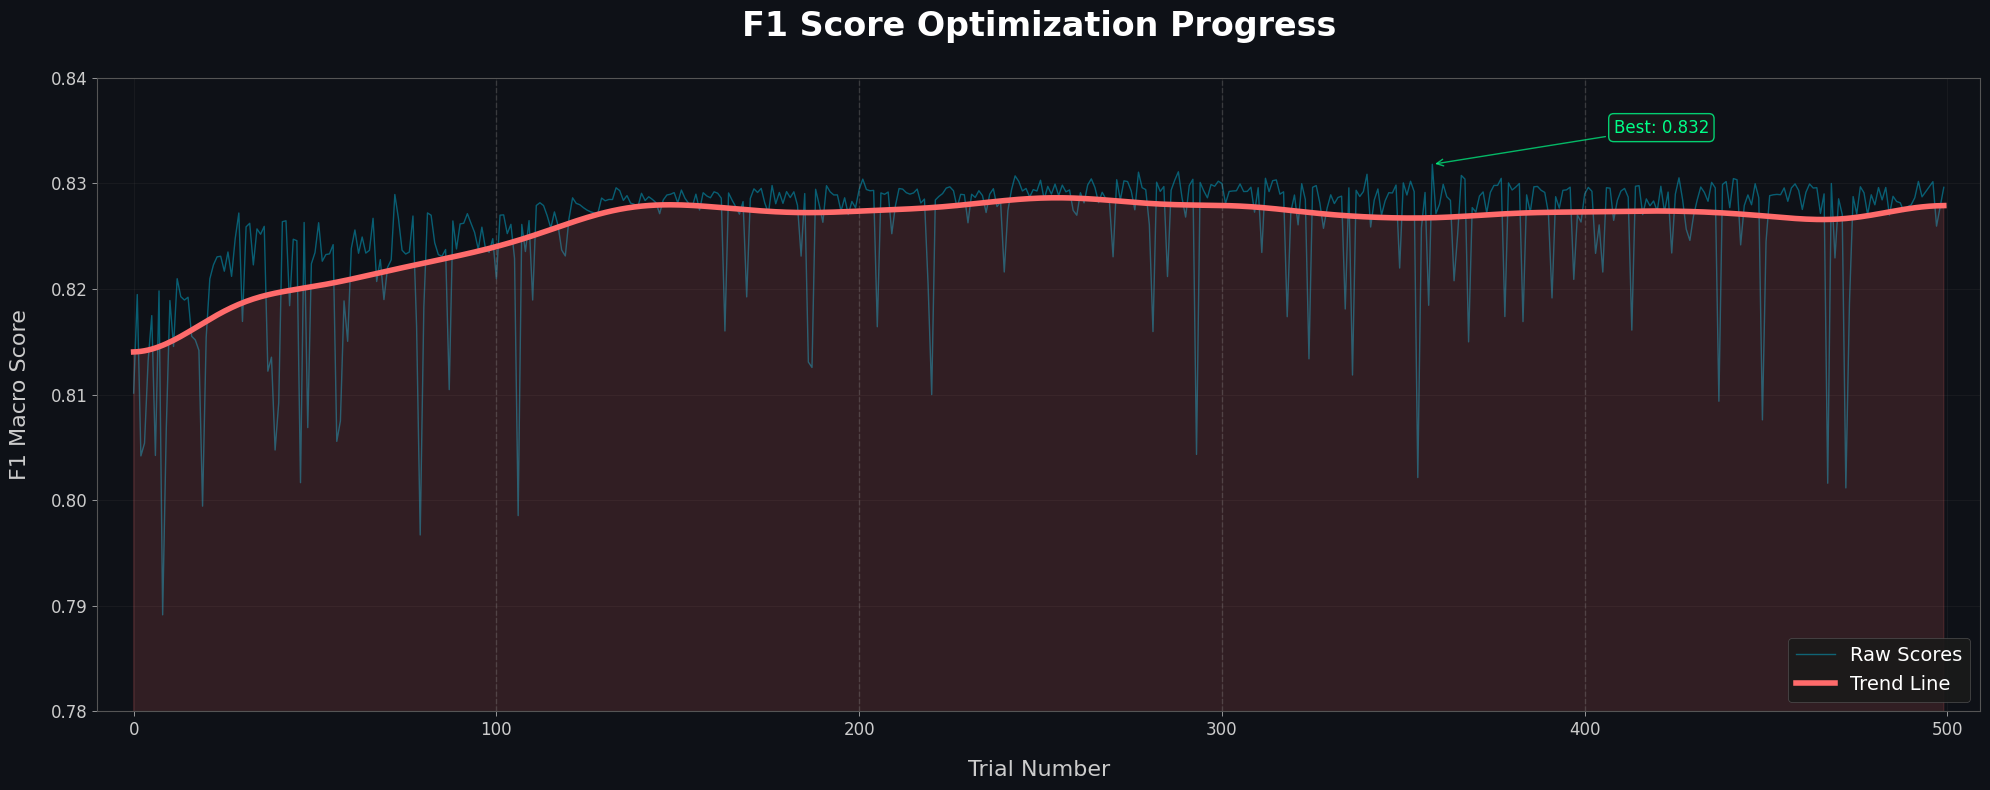

In [55]:
from scipy.ndimage import gaussian_filter1d
plt.style.use('dark_background')
sns.set_palette("husl")

# Prepare data for plotting
x = study_df['trial_number'].values
y = study_df['f1_macro'].values
# Create smooth trend line
y_smooth = gaussian_filter1d(y, sigma=len(y)//30)  # Adaptive smoothing

# Create single enhanced plot
fig, ax = plt.subplots(1, 1, figsize=(20, 8))
fig.patch.set_facecolor('#0e1117')
ax.set_facecolor('#0e1117')

# Main data visualization with enhanced aesthetics
ax.plot(x, y, color='#00d4ff', alpha=0.4, linewidth=1, label='Raw Scores', zorder=1)
ax.plot(x, y_smooth, color='#ff6b6b', linewidth=4, label='Trend Line', zorder=3)

# Add subtle fill under the trend line
ax.fill_between(x, y_smooth, alpha=0.15, color='#ff6b6b', zorder=2)

# Add performance milestones as subtle vertical lines
milestone_trials = [100, 200, 300, 400]
for trial in milestone_trials:
    if trial <= len(x):
        ax.axvline(x=trial, color='#888888', linestyle='--', alpha=0.3, linewidth=1)

# Enhanced styling
ax.set_title('F1 Score Optimization Progress', 
             fontsize=24, color='white', pad=30, fontweight='bold')
ax.set_xlabel('Trial Number', fontsize=16, color='#cccccc', labelpad=15)
ax.set_ylabel('F1 Macro Score', fontsize=16, color='#cccccc', labelpad=15)

# Refined grid
ax.grid(True, alpha=0.2, color='#555555', linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Enhanced legend
legend = ax.legend(loc='lower right', frameon=True, 
                  facecolor='#1a1a1a', edgecolor='#555555',
                  fontsize=14, framealpha=0.9)
legend.get_frame().set_linewidth(0.5)

# Styling improvements
ax.tick_params(colors='#cccccc', labelsize=12, width=0.5)
ax.set_ylim(0.78, 0.84)

# Clean spine styling
for spine in ax.spines.values():
    spine.set_edgecolor('#555555')
    spine.set_linewidth(0.8)

# Reduce left and right padding
ax.margins(x=0.02)

# Add subtle performance annotation
best_score = np.max(y)
best_trial = x[np.argmax(y)]
ax.annotate(f'Best: {best_score:.3f}', 
            xy=(best_trial, best_score), 
            xytext=(best_trial + 50, best_score + 0.003),
            fontsize=12, color='#00ff88',
            arrowprops=dict(arrowstyle='->', color='#00ff88', alpha=0.7),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#1a1a1a', 
                     edgecolor='#00ff88', alpha=0.8))

plt.tight_layout()
plt.show()

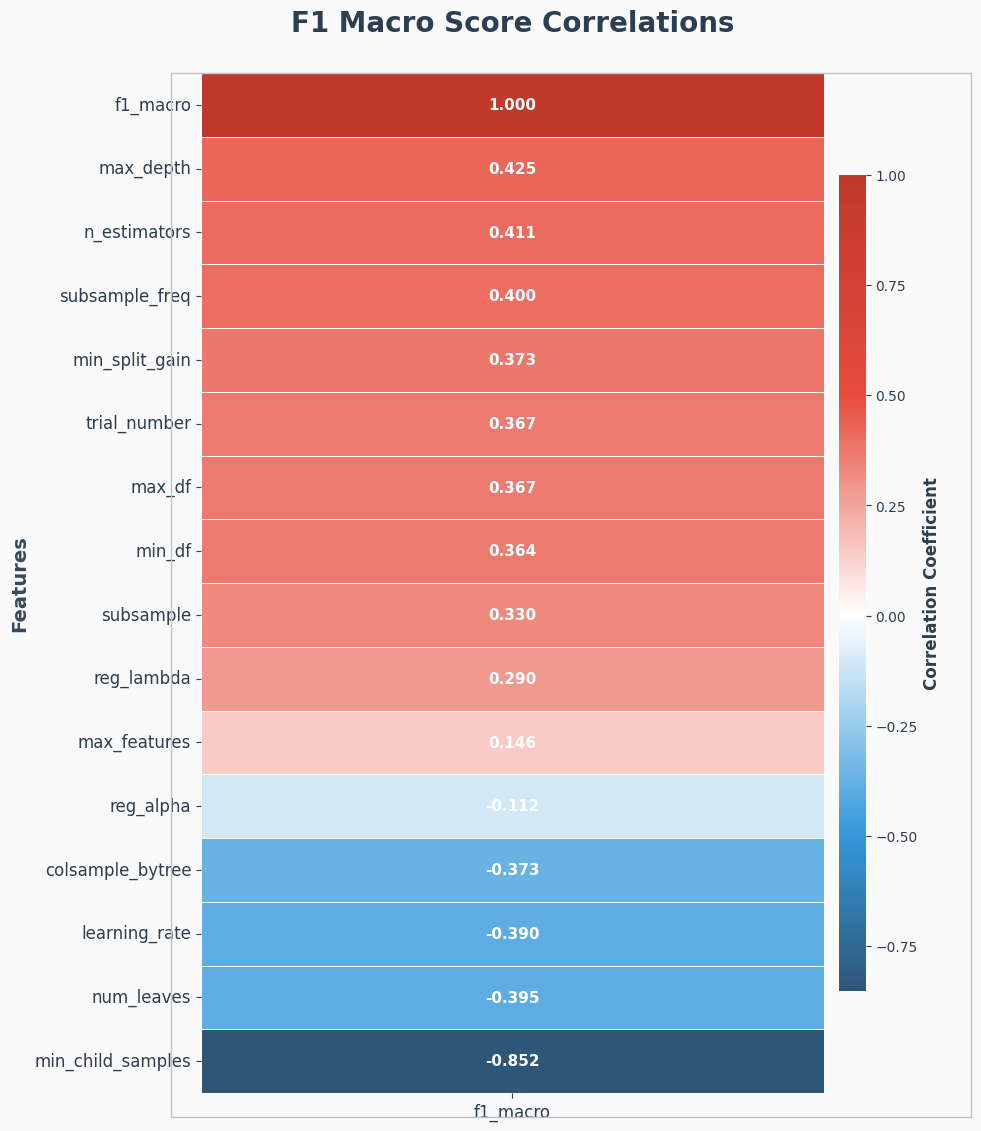

In [42]:
# Create aesthetic correlation heatmap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set modern aesthetic style
plt.style.use('default')
sns.set_palette("husl")

# Select only numeric columns and calculate correlation
corr = study_df.select_dtypes(include=['float64', 'int64']).corr()
f1_corr = corr[['f1_macro']].sort_values(by='f1_macro', ascending=False)

# Create figure with custom styling
fig, ax = plt.subplots(figsize=(10, 12))

# Create custom colormap with gradient
colors = ['#2C3E50', '#3498DB', '#FFFFFF', '#E74C3C', '#C0392B']
n_bins = 256
cmap = sns.blend_palette(colors, n_colors=n_bins, as_cmap=True)

# Create the heatmap with enhanced aesthetics
heatmap = sns.heatmap(
    f1_corr, 
    annot=True, 
    cmap=cmap,
    center=0,
    square=False,
    cbar_kws={
        'shrink': 0.8,
        'aspect': 30,
        'pad': 0.02,
        'label': 'Correlation Coefficient'
    },
    annot_kws={
        'size': 11,
        'weight': 'bold',
        'color': 'white'
    },
    fmt='.3f',
    linewidths=0.5,
    linecolor='white'
)

# Customize the plot aesthetics
ax.set_title('F1 Macro Score Correlations', 
             fontsize=20, 
             fontweight='bold', 
             pad=30,
             color='#2C3E50')

ax.set_xlabel('', fontsize=14, fontweight='bold', color='#34495E')
ax.set_ylabel('Features', fontsize=14, fontweight='bold', color='#34495E')

# Style the tick labels
ax.tick_params(axis='y', labelsize=12, colors='#2C3E50', labelrotation=0)
ax.tick_params(axis='x', labelsize=12, colors='#2C3E50')

# Add subtle grid
ax.grid(False)

# Customize colorbar
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=10, colors='#2C3E50')
cbar.ax.yaxis.label.set_color('#2C3E50')
cbar.ax.yaxis.label.set_fontsize(12)
cbar.ax.yaxis.label.set_fontweight('bold')

# Remove spines for cleaner look
for spine in ax.spines.values():
    spine.set_visible(False)

# Add subtle background
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

# Adjust layout with better spacing
plt.tight_layout()
plt.subplots_adjust(top=0.95, bottom=0.1, left=0.15, right=0.9)

# Add a subtle border around the plot
rect = plt.Rectangle((0.12, 0.08), 0.8, 0.87, 
                    fill=False, 
                    edgecolor='#BDC3C7', 
                    linewidth=1, 
                    transform=fig.transFigure)
fig.patches.append(rect)

plt.show()

In [42]:
# Enhanced summary with formatting
print("\n" + "="*70)
print("HYPERPARAMETER OPTIMIZATION DASHBOARD")
print("="*70)
print(f"Best F1-macro score: {study.best_value:.4f}")
print(f"Mean F1-macro score: {df['f1_macro'].mean():.4f}")
print(f"Standard deviation: {df['f1_macro'].std():.4f}")
print(f"Total completed trials: {len(df)}")
print(f"Score improvement: {((study.best_value - df['f1_macro'].iloc[0]) / df['f1_macro'].iloc[0] * 100):.2f}%")

print(f"\nOPTIMAL HYPERPARAMETERS:")
print("-" * 40)
for param_name, param_value in study.best_params.items():
    if isinstance(param_value, float):
        print(f"  {param_name}: {param_value:.6f}")
    else:
        print(f"  {param_name}: {param_value}")

print(f"\nTOP 5 MOST INFLUENTIAL PARAMETERS:")
print("-" * 50)
for i, (param, corr) in enumerate(zip(param_names[:5], correlations[:5])):
    importance_level = "HIGH" if corr > 0.3 else "MEDIUM" if corr > 0.2 else "LOW"
    print(f"  {i+1}. [{importance_level}] {param}: {corr:.4f}")

print(f"\nTOP 5 PERFORMING TRIALS:")
print("-" * 45)
top_trials = df.nlargest(5, 'f1_macro')
for idx, (_, row) in enumerate(top_trials.iterrows()):
    rank = f"#{idx+1}"
    print(f"  {rank} Trial #{int(row['trial_number'])}: F1-macro = {row['f1_macro']:.4f}")

print("\n" + "="*70)
print("Visualization complete! Happy optimizing!")
print("="*70)


HYPERPARAMETER OPTIMIZATION DASHBOARD
Best F1-macro score: 0.8318
Mean F1-macro score: 0.8258
Standard deviation: 0.0062
Total completed trials: 500
Score improvement: 2.67%

OPTIMAL HYPERPARAMETERS:
----------------------------------------
  num_leaves: 25
  max_depth: 13
  learning_rate: 0.020794
  n_estimators: 1700
  subsample: 0.915939
  colsample_bytree: 0.474195
  reg_alpha: 0.071714
  reg_lambda: 0.737060
  min_child_samples: 10
  min_split_gain: 0.491569
  subsample_freq: 10
  max_features: 9006
  min_df: 10
  max_df: 0.978396
  ngram_range: 1_2
  sublinear_tf: False

TOP 5 MOST INFLUENTIAL PARAMETERS:
--------------------------------------------------
  1. [HIGH] min_child_samples: 0.8523
  2. [HIGH] max_depth: 0.4252
  3. [HIGH] n_estimators: 0.4108
  4. [HIGH] subsample_freq: 0.3996
  5. [HIGH] num_leaves: 0.3947

TOP 5 PERFORMING TRIALS:
---------------------------------------------
  #1 Trial #358: F1-macro = 0.8318
  #2 Trial #288: F1-macro = 0.8311
  #3 Trial #277: F1-